In [1]:
!pip install sklearn-genetic sklearn-genetic-opt

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, auc,roc_curve
from sklearn.utils.class_weight import compute_class_weight

from sklearn.svm import SVC

from sklearn_genetic import GAFeatureSelectionCV
from sklearn_genetic.space import Continuous, Categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

2026-04-08 10:49:10.154699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775645350.425595      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775645350.507778      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775645351.169865      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775645351.169913      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775645351.169916      24 computation_placer.cc:177] computation placer alr

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
data_dir = "/kaggle/input/datasets/revanthdora/updated-dataset/Updated_Dataset"

filepaths = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(label)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

df.head()

,filename,class
0,/kaggle/input/datasets/revanthdora/updated-dat...,Stroke
1,/kaggle/input/datasets/revanthdora/updated-dat...,Stroke
2,/kaggle/input/datasets/revanthdora/updated-dat...,Stroke
3,/kaggle/input/datasets/revanthdora/updated-dat...,Stroke
4,/kaggle/input/datasets/revanthdora/updated-dat...,Stroke


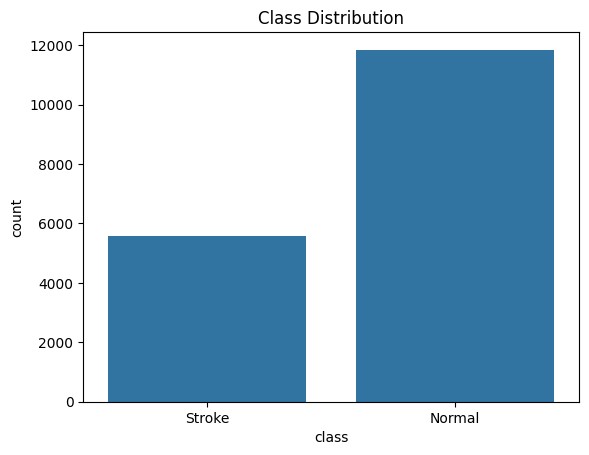

In [5]:
sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.show()

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42)

In [7]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='class',
                                        target_size=img_size, class_mode='binary', batch_size=batch_size)

val_gen = datagen.flow_from_dataframe(val_df, x_col='filename', y_col='class',
                                      target_size=img_size, class_mode='binary', batch_size=batch_size)

test_gen = datagen.flow_from_dataframe(test_df, x_col='filename', y_col='class',
                                       target_size=img_size, class_mode='binary', batch_size=batch_size, shuffle=False)

Found 12201 validated image filenames belonging to 2 classes.
Found 2614 validated image filenames belonging to 2 classes.
Found 2615 validated image filenames belonging to 2 classes.


In [8]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_model = Model(inputs=base_model.input, outputs=x)

I0000 00:00:1775645403.757122      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775645403.763924      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
def extract_features(model, generator):
    generator.reset()
    features = []
    labels = []
    steps = int(np.ceil(generator.samples / generator.batch_size))

    for i in range(steps):
        x_batch, y_batch = next(generator)
        feat = model.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)

    return np.vstack(features), np.hstack(labels)

In [10]:
X_train, y_train = extract_features(feature_model, train_gen)
X_val, y_val = extract_features(feature_model, val_gen)
X_test, y_test = extract_features(feature_model, test_gen)

I0000 00:00:1775645410.984420      78 service.cc:152] XLA service 0x7a02880035e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775645410.984457      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775645410.984461      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775645412.392503      78 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775645419.032875      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [11]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)

class_weights = dict(zip(np.unique(y_train), class_weights))

In [12]:
ga = GAFeatureSelectionCV(
    estimator=SVC(kernel='rbf',class_weight=class_weights),
    cv=3,
    scoring="recall",
    population_size=15,
    generations=15,
    n_jobs=-1
)

In [13]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("ga", ga)
])

In [14]:
X_train_opt = pipeline.fit_transform(X_train, y_train)
X_val_opt = pipeline.transform(X_val)
X_test_opt = pipeline.transform(X_test)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.742525	0.00938646 	0.765729   	0.728644   
1  	30    	0.752075	0.00503908 	0.758827   	0.73939    
2  	30    	0.752552	0.0040307  	0.758827   	0.744755   
3  	30    	0.751392	0.00557364 	0.758827   	0.740151   
4  	30    	0.753268	0.00541273 	0.758827   	0.745525   
5  	30    	0.75175 	0.00475571 	0.758827   	0.745525   
6  	30    	0.750983	0.00680329 	0.758827   	0.738105   
7  	30    	0.756507	0.00554146 	0.767009   	0.74297    
8  	30    	0.755705	0.00841642 	0.767009   	0.736833   
9  	30    	0.754034	0.00782534 	0.763428   	0.737855   
10 	30    	0.755262	0.00572791 	0.763428   	0.740925   
11 	30    	0.754392	0.00680727 	0.761126   	0.734786   
12 	30    	0.753761	0.00485812 	0.759083   	0.742968   
13 	30    	0.754869	0.00401442 	0.759083   	0.745782   
14 	30    	0.75526 	0.00417151 	0.764707   	0.746294   
15 	30    	0.753795	0.00652755 	0.764707   	0.741944   


In [15]:
def reshape_for_lstm(X):
    return X.reshape(X.shape[0], 1, X.shape[1])

X_train_lstm = reshape_for_lstm(X_train_opt)
X_val_lstm = reshape_for_lstm(X_val_opt)
X_test_lstm = reshape_for_lstm(X_test_opt)

In [16]:
bilstm_model = Sequential([
    Bidirectional(LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]))),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = bilstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7112 - loss: 0.5447 - val_accuracy: 0.8290 - val_loss: 0.3898
Epoch 2/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8630 - loss: 0.3224 - val_accuracy: 0.8531 - val_loss: 0.3535
Epoch 3/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9187 - loss: 0.2014 - val_accuracy: 0.8638 - val_loss: 0.3610
Epoch 4/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9525 - loss: 0.1256 - val_accuracy: 0.8676 - val_loss: 0.3991
Epoch 5/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9693 - loss: 0.0823 - val_accuracy: 0.8669 - val_loss: 0.4600
Epoch 6/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9788 - loss: 0.0584 - val_accuracy: 0.8680 - val_loss: 0.5045
Epoch 7/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9824 - loss: 0.0458 - val_accuracy: 0.8650 - val_loss: 0.4990
Epoch 8/15
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9860 - loss: 0.0412 - val_accuracy: 0.

In [19]:
loss, acc = bilstm_model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy:{acc*100:.2f}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8681 - loss: 0.6272
Test Accuracy:86.85


In [20]:
y_pred_proba = bilstm_model.predict(X_test_lstm)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90      1777
         1.0       0.81      0.77      0.79       838

    accuracy                           0.87      2615
   macro avg       0.85      0.84      0.85      2615
weighted avg       0.87      0.87      0.87      2615



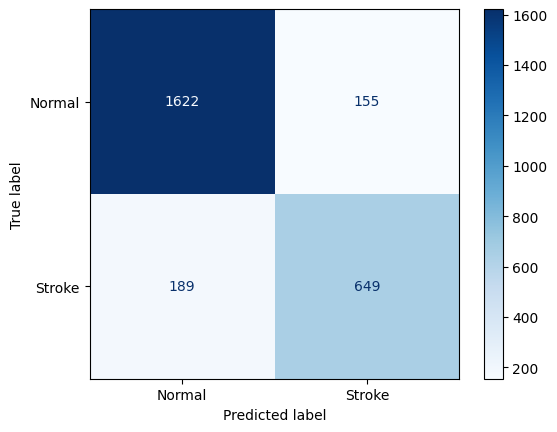

In [21]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Normal','Stroke']
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap="Blues")

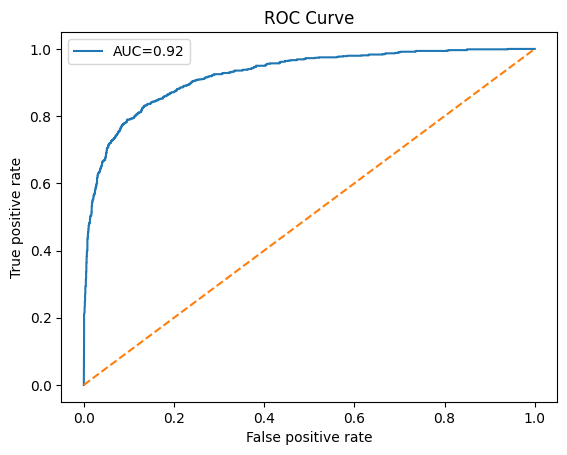

In [22]:
fpr,tpr, _ = roc_curve(y_test,y_pred_proba)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1],linestyle = '--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [23]:
bilstm_model.save("/kaggle/working/bilstm_final_model.keras")
feature_model.save("/kaggle/working/InceptionV3(bilstm).keras")
joblib.dump(pipeline, "/kaggle/working/pipeline(bilstm).pkl")

['/kaggle/working/pipeline(bilstm).pkl']

In [24]:
bilstm_model = keras.models.load_model("/kaggle/working/bilstm_final_model.keras")
features_model = keras.models.load_model("/kaggle/working/InceptionV3(bilstm).keras")
pipeline = joblib.load("/kaggle/working/pipeline(bilstm).pkl")